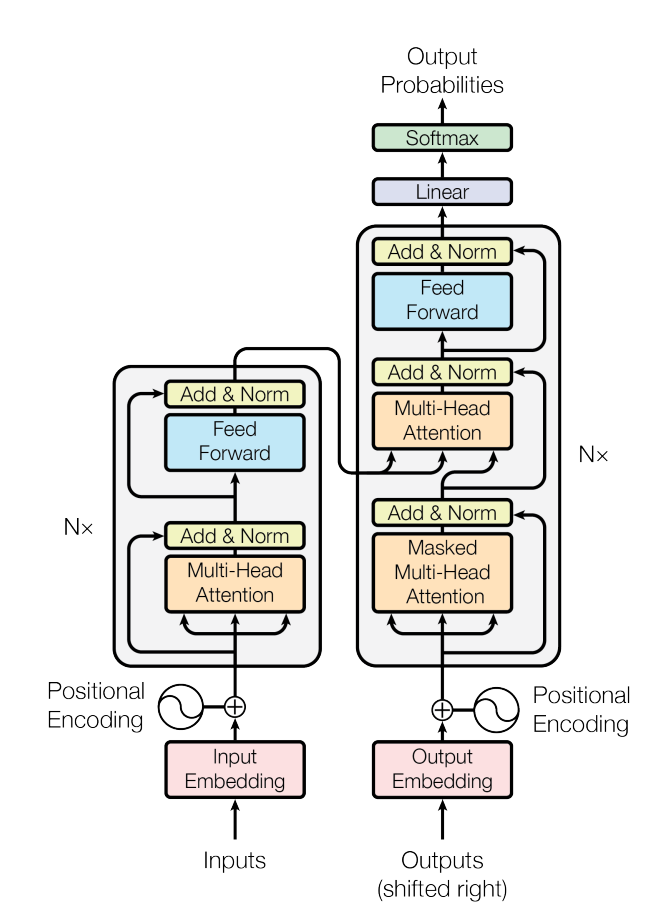

ในที่นี้เราจะสร้างเเบบ gpt คือ decoder only เพื่อเป็นโมเดลถามตอบใน autoregressive ในเชิงที่ตอนเทรนมี masking คือมันจะไม่เห้นทุกอย่างพร้อมกัน จะปิดไม่ให้เห็นตัวถัดไปด้วยวิธีสร้าง triangular matrix ผ่าน .trill เเล้วทำให้ผลลัพธ์เป็น diagonalize

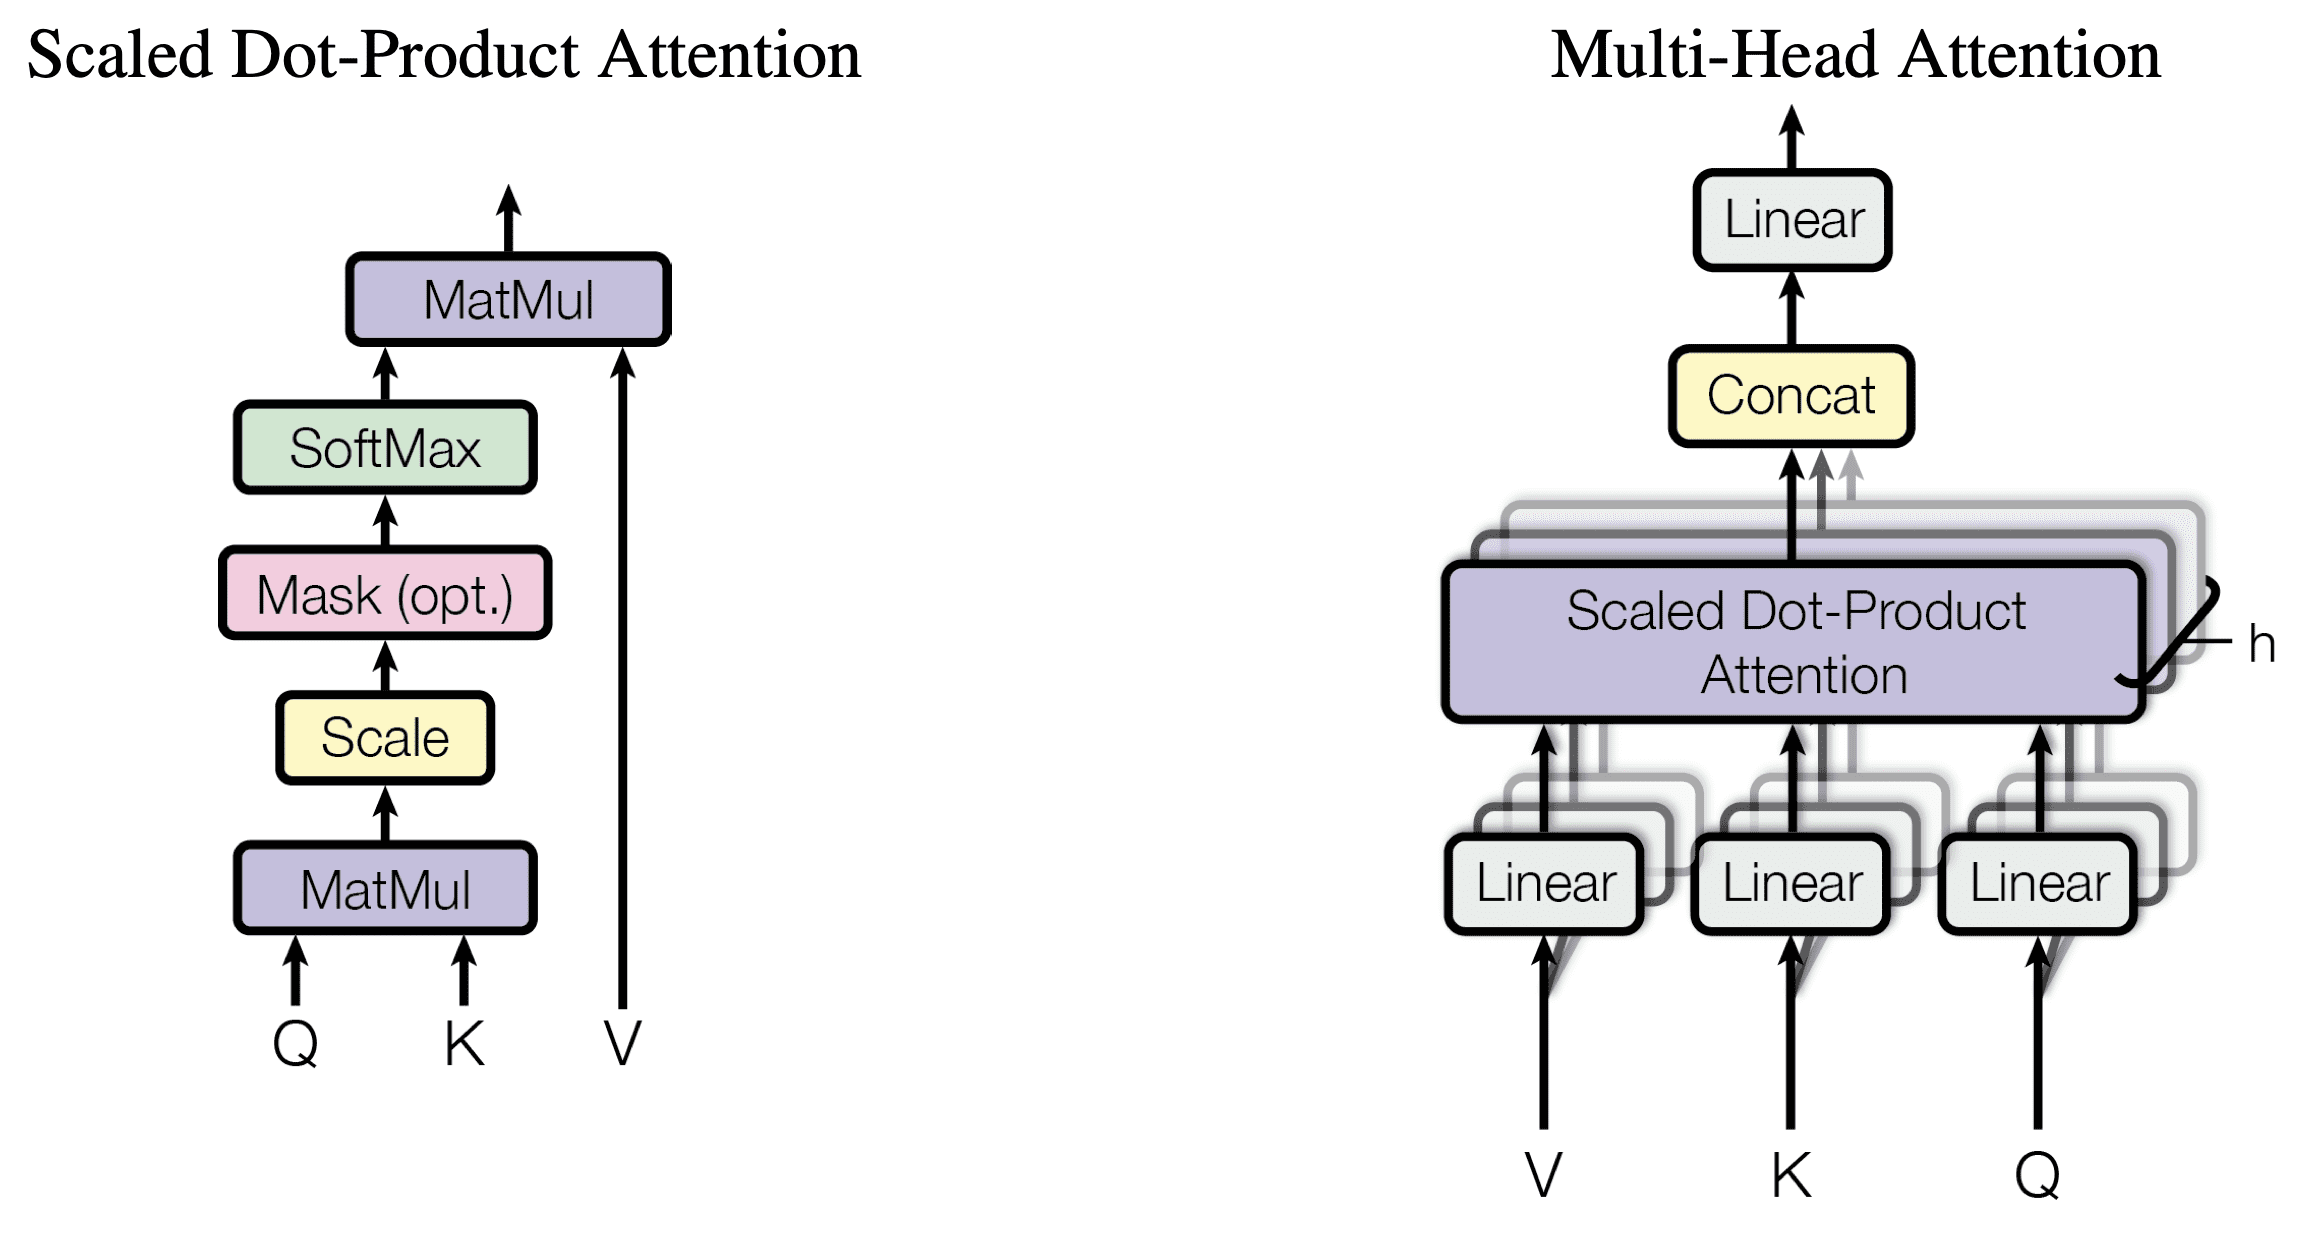

# ขั้น 0: เริ่มที่ Tokenization
ขั้นตอน tokenize จริงๆคือขั้น 0 ไม่มีใน diagram ตัว transformer block ของ attention is all you need

จะโหลด data มาก่อน
data เป็น txt  ที่เป็นเกี่ยวกับ shakespear เอามาจาก karpathy
github ที่อ้างอิงคือ gpt-dev.ipynb

จะใช้ตัว Tokenization ของตัว gpt2 ซึ่งต่างจากคลิปของ nanogpt ที่เทรนตัว tokenizer ขึ้นมาเอง ซึ่งก็ต้องเช็คขนาดใน Tensor ทั้ง 3 ส่วนให้ดีว่าตรงมั้ย

In [20]:
import urllib.request
from transformers import AutoTokenizer
import torch
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
urllib.request.urlretrieve(url, "input.txt")
with open("input.txt", "r") as f:
    text = f.read()
tokenizer = AutoTokenizer.from_pretrained("gpt2")
encoded = tokenizer(text, return_tensors="pt")
x = encoded["input_ids"]
B, T = x.shape
print(x.shape)

Token indices sequence length is longer than the specified maximum sequence length for this model (338025 > 1024). Running this sequence through the model will result in indexing errors


torch.Size([1, 338025])


หมายความว่าตัวโมเดล gpt ( ไม่ใช้ตัว tokenizer ) รับ length ได้เเค่ 1024 เเต่ไอนี่มันคือ matrix ที่ 1 row มี 338,025 column (torch.Size([1, 338025]))เเน่นอนว่าเราไม่ได้เทรนทั้งหมดในทีเดียว จะมีการเเบ่งเป็น chunks เเล้วมีการนำเลือกเทรนอีกที

เราจะเเยก train/ val data โดยเเบ่ง train 90/ val 10 ==> train = 304,222 เเละ val = 338,802

เเละอย่างที่บอกว่ามันเป็นเเสนก็เยอะเกินเราเลยจะเเบ่งเป็น chunks 16 chunks/ chunks ละ 256 token ids ( be aware ว่านี่ยังไม่ใช่การ embed ถ้า embed เเปลว่ามันต้องไปอยู่ใน span ของ data ใน dataset ทั้งหมด

In [21]:
block_size = 256
data = x.squeeze(0)  #อย่างลืมว่า size x = [1,300k] ควรปรับให้เป็น 1D
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]
def get_batch(split, batch_size=4):
    data = train_data if split == "train" else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    xb = torch.stack([data[i : i+block_size] for i in ix])
    yb = torch.stack([data[i+1 : i+block_size+1] for i in ix])
    return xb, yb

xb, yb = get_batch("train")
print(xb.shape)
print(yb.shape)

torch.Size([4, 256])
torch.Size([4, 256])


ที่ทำ x กับ y ให้เหลื่อมกัน 1 เพราะว่าไอเดียของการทำ LLM ในเชิงนี้ทั้งหมดคือการทำ

$P$( $x_{t+1}$| $x_{0->t}$)

ฉะนั้น xb เลยเเทน $x_{0->t}$

เเละ yb เเทน $x_{t+1}$

เเละนำ get batch คือการ "เลือก" เทรนคือสุ่มๆหยิบ batch มาเทรนนั่นเเหละ

# ขั้น 1: Embedding

เราจะสร้างการ embedding หมายความว่าเเต่ละ token id เราจะ assign ให้มันกลายเป็นเวกเตอร์ บวกกับเราจะทำ positional mebedding ให้มัน เเต่เราจะไม่ได้โค้ดมันตอนนี้เลยซะทีเดียวเพราะมันจะต้องไปอยู่ในคลาส

เลยจะเเนะนำขั้นตอนคือทำ nn.Embedding (คือ method, เราต้องเอาตัวที่เรา assign ให้เป็น nn.embedding ให้ไปใช้อีกทีนึงเอง)

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
#สร้างเมทริกมั่วๆ rank 1 มาก่อน
x = torch.randint(0, 4, (1,4)) # nn.Embedding รับเเค่ int จะ torch.rand ไม่ได้
x

tensor([[3, 0, 2, 3]])

In [7]:
embed = nn.Embedding(4,4)
embed(x)

tensor([[[-0.1976, -1.1827, -0.4187, -0.6403],
         [-1.0915, -1.4483, -0.1074,  0.3386],
         [ 1.8156, -2.0065, -0.4627,  0.9407],
         [-0.1976, -1.1827, -0.4187, -0.6403]]], grad_fn=<EmbeddingBackward0>)

ผลสุดท้ายจะเป็นเวกเตอร์ขนาดตามที่เราใส่ไป นี่หละคือจุดที่เราควรจะได้ square matrix ซึ่งเเต่ละ row คือเเต่ละ token id $$W_E \in \mathbb{R}^{4 \times 4} =
\begin{bmatrix}
\text{row}_0 \\
\text{row}_1 \\
\text{row}_2 \\
\text{row}_3
\end{bmatrix}$$

$$\text{embed}(x) =
\begin{bmatrix}
W_E[3] \\
W_E[0] \\
W_E[2] \\
W_E[3]
\end{bmatrix} =
\begin{bmatrix}
-0.1976, & -1.1827, & -0.4187, & -0.6403 \\
-1.0915, & -1.4483, & -0.1074, & -0.3386 \\
-1.8156, & -2.0065, & -0.4627, & -0.9407 \\
-0.1976, & -1.1827, & -0.4187, & -0.6403
\end{bmatrix}$$

ซึ่ง 1 กับ 4 มันซ้ำเพราะเดิมเเล้เป็น 3 กับ 3 เหมือนกันจาก x

วิธีการเลือก argument คือ $$\text{nn.Embedding}(\underbrace{n}_{\text{must be} > \max(x)}, \ \underbrace{d}_{\text{your choice}})$$

ในงานจริง n จะเป็น vocab size / d เป็น embedding dim

ส่วนที่มันซ้ำส่วนนึงก็คือมาจากการสุ่มด้วย ในงานจริก็ว้ำได้คือคำเดียวกับก็มาซ้ำกันได้ => มันเลยต้องมี positional embedding


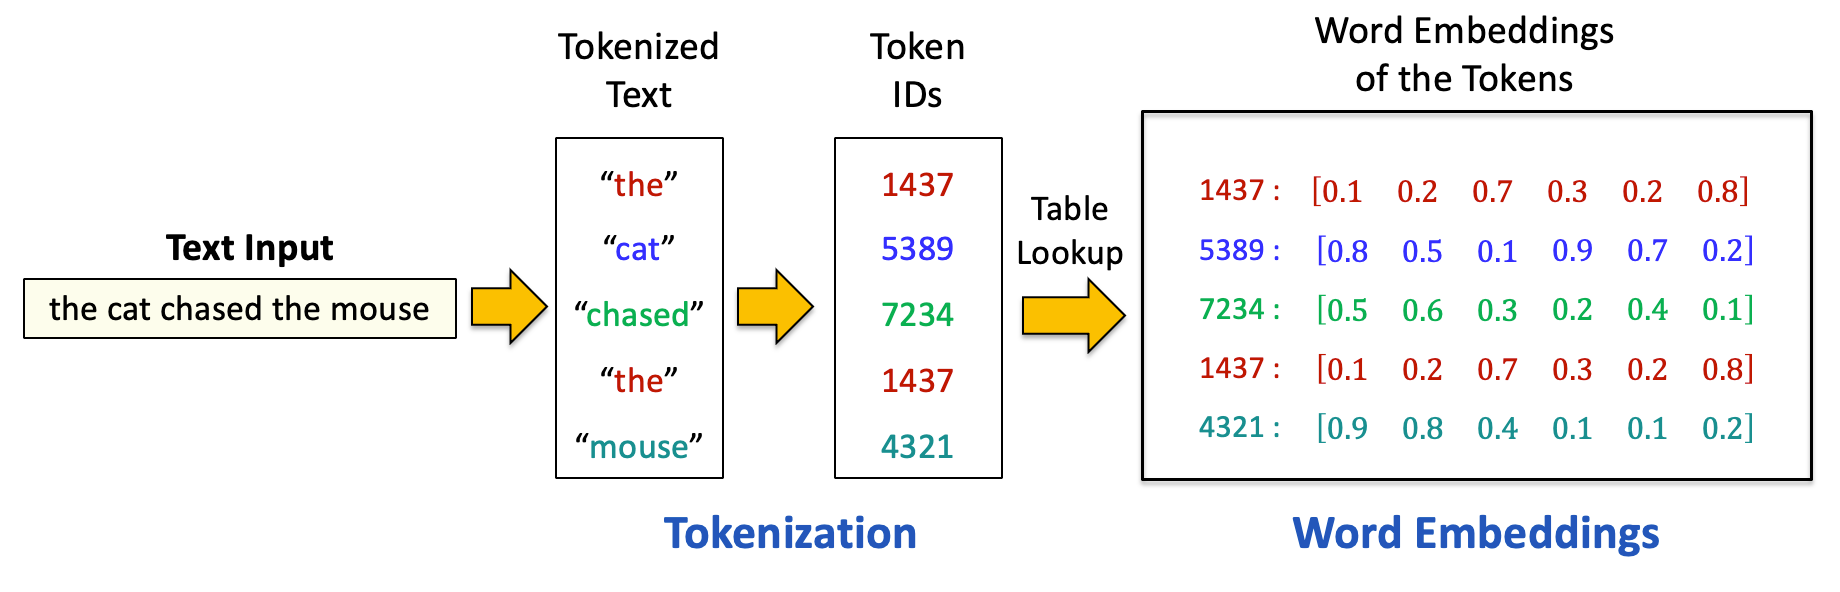

ต่อมาจะมีการทำ positional embedding อีกซึ่ง size ของทั้ง embedding/ pos_embed จะ set up ยังไงก็ตามนนี้
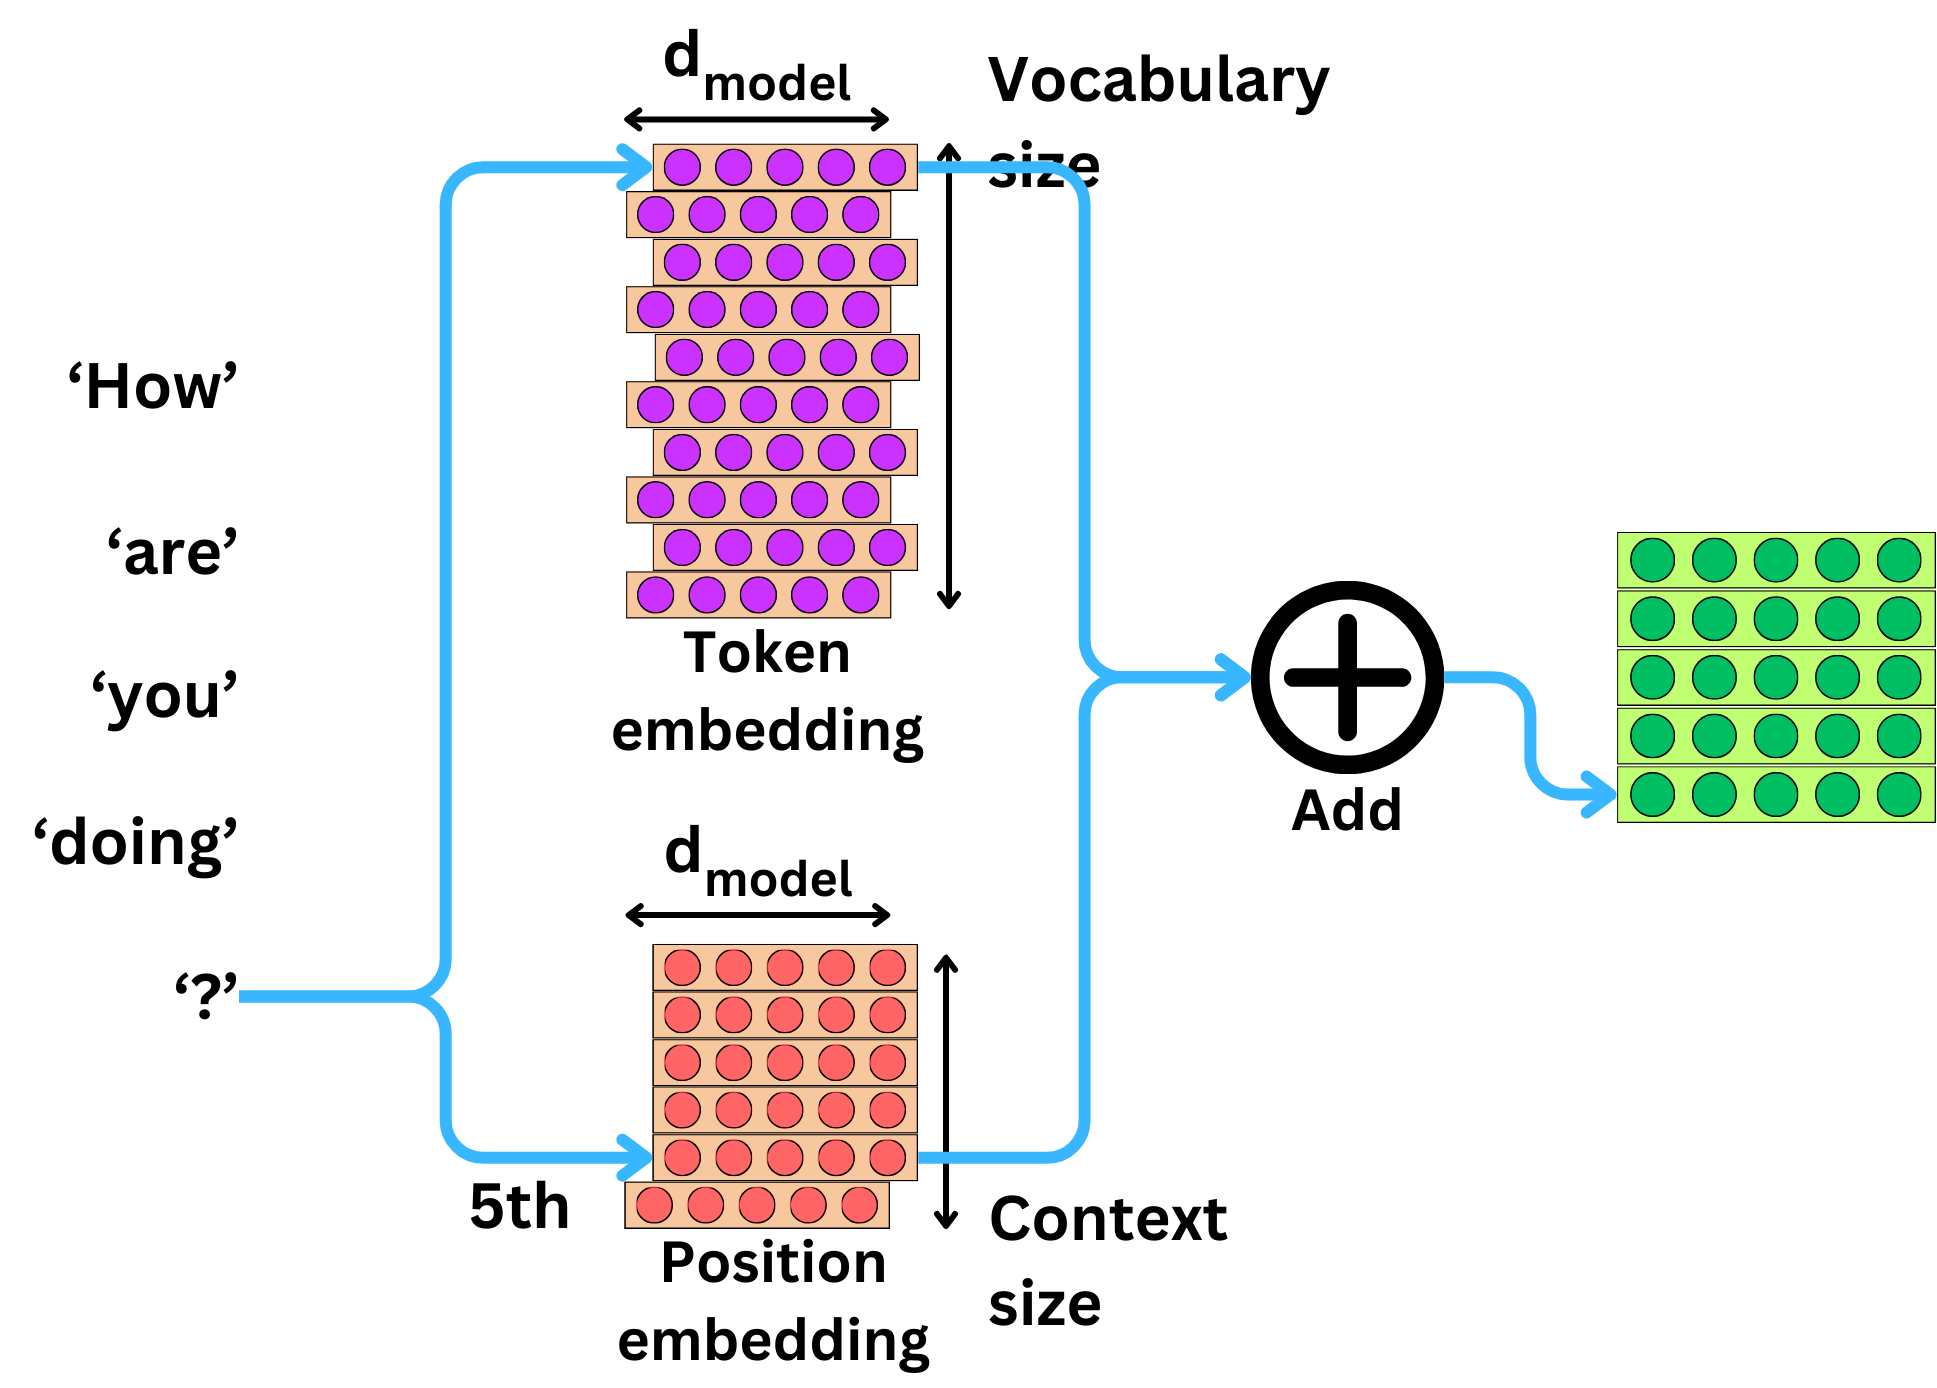

# ขั้น 2 attn
ตาม scaled dot product attention

In [9]:
B,T = x.shape
print(B)
print(T)
q_linear = nn.Linear(4,4, bias=  False)
k_linear = nn.Linear(4,4, bias=  False)
v_linear = nn.Linear(4,4, bias=  False)
embedding_dim = 4
x_embed = torch.rand(B, T, embedding_dim)
print(f"value of x is {x} with size of {x.size()}")
print(f"after embedding x_embed is {x_embed} with size of {x_embed.size()}")
q = q_linear(x_embed)
k = k_linear(x_embed)
v = v_linear(x_embed)
print(f"value of q is {q}")
print(f"size of q is {q.size()}")
score = q @ k.transpose(-2,-1)
score = F.softmax(score,dim=-1)
out = score @ v
print(out.shape)
print(out)

1
4
value of x is tensor([[3, 0, 2, 3]]) with size of torch.Size([1, 4])
after embedding x_embed is tensor([[[0.3906, 0.0127, 0.6900, 0.1374],
         [0.8051, 0.7389, 0.0346, 0.9443],
         [0.3188, 0.1934, 0.4450, 0.8070],
         [0.8406, 0.8452, 0.8260, 0.9600]]]) with size of torch.Size([1, 4, 4])
value of q is tensor([[[ 0.3644, -0.2536,  0.2718,  0.0636],
         [-0.1420,  0.0121,  0.1754, -0.1703],
         [ 0.0320, -0.0099,  0.1348, -0.1638],
         [ 0.2279, -0.1929,  0.3297, -0.0686]]], grad_fn=<UnsafeViewBackward0>)
size of q is torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
tensor([[[-0.3887, -0.0260, -0.3089,  0.3699],
         [-0.3750, -0.0309, -0.2888,  0.3671],
         [-0.3775, -0.0297, -0.2927,  0.3674],
         [-0.3862, -0.0260, -0.3037,  0.3689]]], grad_fn=<UnsafeViewBackward0>)


นี่ก็คำทำ scale dot product คร่าวๆ ต่อมาจะทำขั้นจริง
สิ่งที่จะเกิดขึ้นจริงคือมีการ scale เเละ mathmul กับตัว value อีกที

In [10]:
head_size = 4
v_linear = nn.Linear(embedding_dim, head_size, bias=False)
v = v_linear(x_embed)
score = score / (head_size ** 0.5)
score = F.softmax(score, dim=-1)
out = score @ v

print(out.shape)
print(out)

torch.Size([1, 4, 4])
tensor([[[ 0.4353, -0.3350, -0.0675, -0.3932],
         [ 0.4338, -0.3330, -0.0670, -0.3913],
         [ 0.4340, -0.3333, -0.0671, -0.3916],
         [ 0.4348, -0.3346, -0.0675, -0.3927]]], grad_fn=<UnsafeViewBackward0>)


ที่ทำมาคือ 1 head ของจริงจะมีหลายๆ head จะมีกี่่  head ก็ตาม num_heads เลย
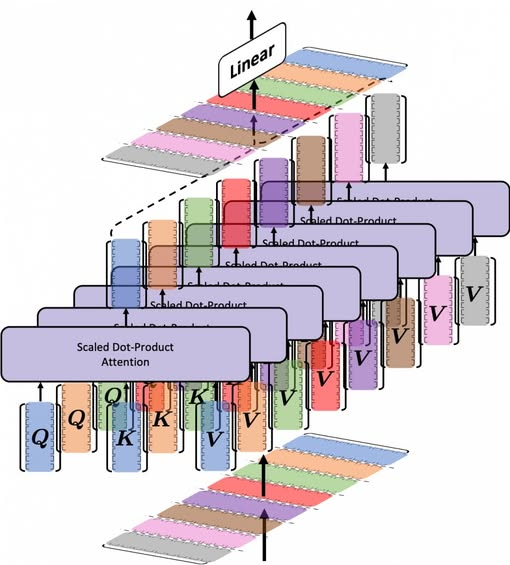

ก็คือไอที่เหลื่อมๆโดยมันจะ run parallel กันเลย

# ขั้น 3 multihead attention

In [11]:
class SingleHead(nn.Module):
      def __init__(self, embedding_dim, head_size):
        super().__init__()
        self.q = nn.Linear(embedding_dim, head_size, bias=False)
        self.k = nn.Linear(embedding_dim, head_size, bias=False)
        self.v = nn.Linear(embedding_dim, head_size, bias=False)
        self.head_size = head_size

      def forward(self, x):
        q = self.q(x)
        k = self.k(x)
        v = self.v(x)
        score = q @ k.transpose(-2, -1) / (self.head_size ** 0.5)
        score = F.softmax(score, dim=-1)
        return score @ v

class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, embedding_dim, head_size):
        super().__init__()
        self.heads = nn.ModuleList([
            SingleHead(embedding_dim, head_size) for _ in range(num_heads)  #รัน parallel กัน
        ])
        self.proj = nn.Linear(num_heads * head_size, embedding_dim)

    def forward(self, x):
        # รัน attention แต่ละ head แล้ว concat ผลลัพธ์
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        return self.proj(out)  # project กลับไปเป็น embedding_dim
embedding_dim = 4
num_heads = 2
head_size = embedding_dim // num_heads  # = 2

B, T = 1, 4
x_embed = torch.rand(B, T, embedding_dim)

mha = MultiHeadAttention(num_heads=num_heads, embedding_dim=embedding_dim, head_size=head_size)
out = mha(x_embed)

print(f"Input shape:  {x_embed.shape}")
print(f"Output shape: {out.shape}")
print(out)

Input shape:  torch.Size([1, 4, 4])
Output shape: torch.Size([1, 4, 4])
tensor([[[ 0.1489, -0.5584,  0.1408, -0.1094],
         [ 0.1503, -0.5595,  0.1402, -0.1078],
         [ 0.1481, -0.5574,  0.1408, -0.1102],
         [ 0.1489, -0.5584,  0.1402, -0.1095]]], grad_fn=<ViewBackward0>)


In [ ]:
x_embed

  ├── [Head 1] ──┐
  ├── [Head 2] ──┤ concat → proj → output
  └── [Head N] ──┘

note ว่าเรายังไมไ่ด้ทำ masking ซึ่งเดี๋ยวจะไปทำอีกทีตอนของเทรนจริง

ที่เราทำทั้งหมดอยู่ตรงนี้ 1 ช่อง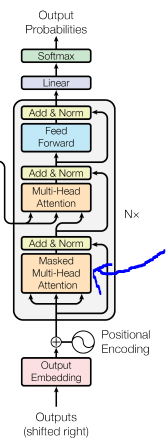

# Feed Forward

อันนี้ไม่มีไรเเค่เอาข้อมูลไปเข้า nn.Linear

In [12]:
class FeedForward(nn.Module):
    def __init__(self, embedding_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embedding_dim, 4 * embedding_dim),  # ขยาย 4 เท่า
            nn.ReLU(),
            nn.Linear(4 * embedding_dim, embedding_dim),  # หดกลับมาเท่าเดิม ที่ต้องเอาเข้า linear เพื่อมันจะได้เรียนรู้อีกที
        )

    def forward(self, x):
        return self.net(x)
ffn = FeedForward(embedding_dim=4)
out_ffn = ffn(x_embed)
print(f"FFN input:  {x_embed.shape}")
print(f"FFN output: {out_ffn.shape}")

FFN input:  torch.Size([1, 4, 4])
FFN output: torch.Size([1, 4, 4])


# ขั้น 5 Transformer block

1 block ของ GPT ประกอบด้วย:
      - Multi-Head Attention
      - Feed-Forward Network
      - LayerNorm และ Residual connection ทั้งคู่  เพื่อ retain ข้อมูล

In [13]:
class TransformerBlock(nn.Module):
    def __init__(self, embedding_dim, num_heads):
        super().__init__()
        head_size = embedding_dim // num_heads
        self.attn = MultiHeadAttention(num_heads, embedding_dim, head_size)
        self.ffn  = FeedForward(embedding_dim)
        self.ln1  = nn.LayerNorm(embedding_dim)
        self.ln2  = nn.LayerNorm(embedding_dim)
    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ffn(self.ln2(x))
        return x
block = TransformerBlock(embedding_dim=4, num_heads=2)
out_block = block(x_embed)
print(f"Block input:  {x_embed.shape}")
print(f"Block output: {out_block.shape}")

Block input:  torch.Size([1, 4, 4])
Block output: torch.Size([1, 4, 4])


In [14]:
out_block

tensor([[[ 0.0036,  0.9121,  1.1649,  0.3139],
         [ 0.5447,  1.4955,  1.1834,  0.2411],
         [-0.1569,  0.5526,  1.0033,  0.9178],
         [ 0.2117,  0.5376,  1.2256,  0.9198]]], grad_fn=<AddBackward0>)

อันนี้คือ 1 block ของจริงจะมี n block ซึ่งไม่เหมือนตัว head ที่มันรัน parallel กันคือเเต่ละบล้อคจะเป็น sequential ต่อกัน
คือ

In [ ]:
  Input tokens
     │
     ▼
[Block 1] → x1
     │
     ▼
[Block 2] → x2
     │
     ▼
[Block 3] → x3
     │
     ▼
  LM Head → predictions

# masking
นี่คือจุดทีทำให้เป็น decoder model
 มาลองดู .trill เป็นการสร้าง triangle matrix

In [15]:
j = torch.rand(4,4)
j = j.tril(diagonal=0)
j

tensor([[0.1814, 0.0000, 0.0000, 0.0000],
        [0.4686, 0.0086, 0.0000, 0.0000],
        [0.8486, 0.3226, 0.5611, 0.0000],
        [0.0171, 0.3986, 0.5210, 0.0406]])

จะเห็นว่าตำเเหน่งที่ถัดจาก diagonal เป็๋น 0 หมดซึ่งในทาง transformer จะเห็นว่ามันรับ input ทั้งหมดใน เวกเตอเดียว เเน่นอนว่าามันไม่เหมอืน RNN ที่ทีละอัน เราเลยปิดมันไม่ให้โกง

เราจะไปใส่ใน forward

In [16]:
def forward(self, x):
    B, T, C = x.shape
    q = self.q(x)
    k = self.k(x)
    v = self.v(x)
    score = q @ k.transpose(-2, -1) / (self.head_size ** 0.5)
    mask = torch.tril(torch.ones(T, T))
    score = score.masked_fill(mask == 0, float('-inf'))
    score = F.softmax(score, dim=-1)
    return score @ v

# pos_embed
เพิ่มก่อน เข้า block

In [17]:
embedding_dim = 4
vocab_size = 50257
block_size  = 8     # ไม่เหมือนจำนวน transformer block

token_embed = nn.Embedding(vocab_size, embedding_dim)
pos_embed   = nn.Embedding(block_size, embedding_dim)

def embed(idx):
    B, T = idx.shape
    tok = token_embed(idx)
    pos = pos_embed(torch.arange(T))
    return tok + pos

# Real shit
จะเห็นดีๆว่ามีบางทีเดลที่ไม่ได้ทำเช่นเเบบ  drop out จะมาใส่ในขั้นนี้ วึ่งจะใส่เพื้่อกัน overfit
ทีนี้จะ connect ทุกอย่างด้วยกัน

ใส่อยู่ 4 จุดคือ หลัง token+pos embed/ หลัง softmax/ หลัง MHA projection/ หลัง FFN

In [18]:
class SingleHead(nn.Module):
    def __init__(self, embedding_dim, head_size, block_size, dropout):
        super().__init__()
        self.q = nn.Linear(embedding_dim, head_size, bias=False)
        self.k = nn.Linear(embedding_dim, head_size, bias=False)
        self.v = nn.Linear(embedding_dim, head_size, bias=False)
        self.head_size = head_size
        self.attn_dropout = nn.Dropout(dropout)
        self.register_buffer('mask', torch.tril(torch.ones(block_size, block_size)))

    def forward(self, x):
        B, T, C = x.shape
        q = self.q(x)
        k = self.k(x)
        v = self.v(x)
        score = q @ k.transpose(-2, -1) / (self.head_size ** 0.5)
        score = score.masked_fill(self.mask[:T, :T] == 0, float('-inf'))
        score = F.softmax(score, dim=-1)
        score = self.attn_dropout(score)
        return score @ v
class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, embedding_dim, head_size, block_size, dropout):
        super().__init__()
        self.heads = nn.ModuleList([
            SingleHead(embedding_dim, head_size, block_size, dropout) for _ in range(num_heads)
        ])
        self.proj = nn.Linear(num_heads * head_size, embedding_dim)
        self.proj_dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        return self.proj_dropout(self.proj(out))


class FeedForward(nn.Module):
    def __init__(self, embedding_dim, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embedding_dim, 4 * embedding_dim),
            nn.ReLU(),
            nn.Linear(4 * embedding_dim, embedding_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)
class TransformerBlock(nn.Module):
    def __init__(self, embedding_dim, num_heads, block_size, dropout):
        super().__init__()
        head_size = embedding_dim // num_heads
        self.attn = MultiHeadAttention(num_heads, embedding_dim, head_size, block_size, dropout)
        self.ffn  = FeedForward(embedding_dim, dropout)
        self.ln1  = nn.LayerNorm(embedding_dim)
        self.ln2  = nn.LayerNorm(embedding_dim)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ffn(self.ln2(x))
        return x


class GPT(nn.Module):
    def __init__(self, vocab_size, embedding_dim, num_heads, num_layers, block_size, dropout=0.1):
        super().__init__()
        self.block_size = block_size
        self.token_embed = nn.Embedding(vocab_size, embedding_dim)
        self.pos_embed   = nn.Embedding(block_size, embedding_dim)
        self.embed_dropout = nn.Dropout(dropout)
        self.blocks  = nn.Sequential(*[
            TransformerBlock(embedding_dim, num_heads, block_size, dropout)
            for _ in range(num_layers)
        ])
        self.ln_f    = nn.LayerNorm(embedding_dim)
        self.lm_head = nn.Linear(embedding_dim, vocab_size, bias=False)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok = self.token_embed(idx)
        pos = self.pos_embed(torch.arange(T, device=idx.device))
        x = self.embed_dropout(tok + pos)
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)

        loss = None
        if targets is not None:
            B, T, V = logits.shape
            loss = F.cross_entropy(logits.view(B*T, V), targets.view(B*T))

        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :]
            probs  = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
            idx = torch.cat([idx, next_token], dim=1)
        return idx

model = GPT(
    vocab_size=50257,
    embedding_dim=32,
    num_heads=4,
    num_layers=3,
    block_size=8,
    dropout=0.1
)
model.train()
idx = torch.randint(0, 50257, (1, 8))
logits, loss = model(idx, targets=idx)
print(f"Loss: {loss.item():.4f}")

model.eval()
out = model.generate(idx, max_new_tokens=5)
print(f"Generated: {out}")

Loss: 10.9692
Generated: tensor([[27142, 45104, 21665, 18918, 16352, 17132, 17559,  2923, 10869, 20757,
         45305, 43126, 20327]])


# training

In [25]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = GPT(
    vocab_size    = tokenizer.vocab_size,
    embedding_dim = 128,
    num_heads     = 4,
    num_layers    = 4,
    block_size    = block_size,  # 256 ที่ assign ไว้แล้ว
    dropout       = 0.1,
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
for epoch in range(500):
    model.train()
    xb, yb = get_batch("train")
    xb, yb = xb.to(device), yb.to(device)

    logits, loss = model(xb, targets=yb)
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    model.eval()
    with torch.no_grad():
        xv, yv = get_batch("val")
        xv, yv = xv.to(device), yv.to(device)
        _, val_loss = model(xv, targets=yv)

    print(f"Epoch {epoch+1} | train loss: {loss.item():.4f} | val loss: {val_loss.item():.4f}")

Parameters: 13,690,368
Epoch 1 | train loss: 10.9905 | val loss: 10.8954
Epoch 2 | train loss: 10.9023 | val loss: 10.7691
Epoch 3 | train loss: 10.8628 | val loss: 10.6352
Epoch 4 | train loss: 10.7192 | val loss: 10.6322
Epoch 5 | train loss: 10.6863 | val loss: 10.5042
Epoch 6 | train loss: 10.5496 | val loss: 10.3881
Epoch 7 | train loss: 10.4607 | val loss: 10.3707
Epoch 8 | train loss: 10.4174 | val loss: 10.2288
Epoch 9 | train loss: 10.2518 | val loss: 10.0991
Epoch 10 | train loss: 10.2381 | val loss: 10.1031
Epoch 11 | train loss: 10.1263 | val loss: 10.0300
Epoch 12 | train loss: 10.0066 | val loss: 9.9186
Epoch 13 | train loss: 10.0937 | val loss: 9.8353
Epoch 14 | train loss: 9.9615 | val loss: 9.8165
Epoch 15 | train loss: 9.9416 | val loss: 9.7978
Epoch 16 | train loss: 9.7625 | val loss: 9.6924
Epoch 17 | train loss: 9.7868 | val loss: 9.6038
Epoch 18 | train loss: 9.6836 | val loss: 9.6681
Epoch 19 | train loss: 9.5533 | val loss: 9.4828
Epoch 20 | train loss: 9.6086 |

In [27]:
model.eval()
with torch.no_grad():
    xb, yb = get_batch("train")
    xb, yb = xb.to(device), yb.to(device)
    logits, loss = model(xb, targets=yb)

print(f"logits shape: {logits.shape}")
print(f"loss: {loss.item():.4f}")
print(f"expected random loss: {torch.log(torch.tensor(tokenizer.vocab_size)).item():.4f}")

logits shape: torch.Size([4, 256, 50257])
loss: 5.4647
expected random loss: 10.8249
